# Estadao Verifica: spider-level EDA

Fixed sections:
1. Run selection and player evidence
2. Volume, temporal coverage, and quality overview
3. Text-length histograms by original_label and standard_label
4. Category, topic/tag, and temporal distribution
5. Missing fields and invalid dates
6. Cleaning and normalization review
7. NLP with stop-word removal, lemmas, and NER
8. Processed JSONL export


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display


def _find_repo_root() -> Path:
    for candidate in (Path.cwd(), *Path.cwd().resolve().parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Repositorio nao encontrado a partir do diretorio atual.")


REPO_ROOT = _find_repo_root()
for path in (REPO_ROOT, REPO_ROOT / "src", REPO_ROOT / "notebooks"):
    path_str = str(path)
    if path_str not in sys.path:
        sys.path.insert(0, path_str)

import eda_utils as eu

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", 160)
sns.set_theme(style="whitegrid", palette="crest")

## Run selection and player evidence

In [2]:
SPIDER = "estadao_verifica"
PLAYER = "Estadao Verifica"
DATA_DIR = eu.resolve_data_dir(str(REPO_ROOT / "data"))
SNAPSHOT_ID = None
BATCH_SIZE = 64

selection = eu.select_spider_run(DATA_DIR, SPIDER)
profile = eu.get_spider_profile(SPIDER)
display(eu.selection_to_frame(selection))
profile

,spider,agency_id,agency_name,selected_run_id,latest_run_id,latest_valid_run_id,fallback_applied,selection_reason,cleaning_flags,diagnostic_run_ids
0,estadao_verifica,estadao_verifica,Estadao Verifica,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,latest_valid_run,"html_unescape, unicode_normalize, collapse_whitespace, light_encoding_fix",


SpiderProfile(spider='estadao_verifica', display_name='Estadao Verifica', analysis_field_order=('title', 'claim', 'summary'), ignored_analysis_titles=frozenset(), dropped_export_titles=frozenset(), extract_label_prefix_before_colon=False, diagnostic_run_ids=(), cleaning_flags=('html_unescape', 'unicode_normalize', 'collapse_whitespace', 'light_encoding_fix'))

In [3]:
runs_df = eu.load_runs_df(DATA_DIR)
spider_runs = runs_df.loc[runs_df["spider"] == SPIDER].sort_values(
    "run_started_at", ascending=False
)
evidence_cols = [
    "run_id",
    "run_started_at",
    "run_finished_at",
    "items_seen",
    "items_stored",
    "items_deduped",
    "items_invalid",
    "has_items_file",
    "is_valid",
]
display(spider_runs[evidence_cols].head(10))

diagnostic_df = eu.diagnostic_runs_df(DATA_DIR, SPIDER)
if not diagnostic_df.empty:
    print("Diagnostic runs configured for this spider:")
    display(diagnostic_df[evidence_cols])

,run_id,run_started_at,run_finished_at,items_seen,items_stored,items_deduped,items_invalid,has_items_file,is_valid
17,20260315T010005Z-1d265f16,2026-03-15 01:00:05+00:00,2026-03-15 07:03:08+00:00,5978,32,5946,0,True,True
1,20260304T055029Z-081fea3a,2026-03-04 05:50:29+00:00,2026-03-04 06:27:49+00:00,5946,5946,0,0,True,True


## Volume, temporal coverage, and quality overview

In [4]:
nlp = eu.load_nlp_model()
raw_df = eu.load_spider_items_df(DATA_DIR, SPIDER, selection.selected_run_id)
selection, processed_records = eu.build_processed_records(
    DATA_DIR,
    SPIDER,
    selection=selection,
    nlp=nlp,
    batch_size=BATCH_SIZE,
)
processed_df = eu.processed_records_to_df(processed_records)
processed_df["published_at_dt"] = pd.to_datetime(
    processed_df["published_at"], utc=True, errors="coerce"
)

overview = pd.DataFrame(
    [
        {
            "player": PLAYER,
            "selected_run_id": selection.selected_run_id,
            "latest_run_id": selection.latest_run_id,
            "fallback_applied": selection.fallback_applied,
            "raw_rows": len(raw_df),
            "processed_rows": len(processed_df),
            "dropped_rows": len(raw_df) - len(processed_df),
            "coverage_start": processed_df["published_at_dt"].min(),
            "coverage_end": processed_df["published_at_dt"].max(),
            "invalid_dates": int(processed_df["published_at_dt"].isna().sum()),
            "missing_original_label": int(processed_df["original_label"].isna().sum()),
        }
    ]
)
display(overview)
display(raw_df.head(3))
display(processed_df.head(3))

,player,selected_run_id,latest_run_id,fallback_applied,raw_rows,processed_rows,dropped_rows,coverage_start,coverage_end,invalid_dates,missing_original_label
0,Estadao Verifica,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,32,32,0,2026-03-04 15:57:06+00:00,2026-03-15 02:39:18+00:00,0,5


,item_id,agency_id,agency_name,spider,source_url,canonical_url,title,published_at,collected_at,claim,summary,verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical
0,4c2d531d4d8d26fac69494b276e5ba74e37f313150ad073b7b8b01b3632b50bf,estadao_verifica,Estadao Verifica,estadao_verifica,https://www.estadao.com.br/estadao-verifica/video-caminhoes-tunel-misseis-ira-falso-inteligencia-artificial/,/estadao-verifica/video-caminhoes-tunel-misseis-ira-falso-inteligencia-artificial/,Vídeo não mostra caminhões com mísseis saindo de túnel no Irã; conteúdo foi criado com IA,2026-03-15T02:39:09+00:00,2026-03-15T02:39:09+00:00,Vídeo mostra caminhões carregados com mísseis saindo de túnel no Irã.,Imagem tem distorções características de arquivos gerados com inteligência artificial,Falso,1,pt-br,BR,[],[],[],ClaimReview,20260315T010005Z-1d265f16,2026-03-15 02:39:09+00:00,2026-03-15 02:39:09+00:00,0.000000,89,69,85,NaN,0.0
1,59403d947743376781218109b37a4cbd0fea7f1aaa97926c08d9472fc5844609,estadao_verifica,Estadao Verifica,estadao_verifica,https://www.estadao.com.br/estadao-verifica/fora-de-contexto-donald-trump-endureceu-tom-brasil/,/estadao-verifica/fora-de-contexto-donald-trump-endureceu-tom-brasil/,Fala de Trump lamentando relação abalada com o Brasil circula fora de contexto,2026-03-15T02:39:09+00:00,2026-03-15T02:39:09+00:00,Donald Trump endureceu o tom contra o Brasil,"Declaração foi feita em setembro de 2025, antes de reaproximação entre os dois países; americano teceu elogios a Lula recentemente",Fora de contexto,3,pt-br,BR,[],[],[],ClaimReview,20260315T010005Z-1d265f16,2026-03-15 02:39:09+00:00,2026-03-15 02:39:09+00:00,0.000000,78,45,130,NaN,0.0
2,0a26335ecc0a19fb79aba59d86627ff0b64211a9ae5583bb506e6ff40f6daeb9,estadao_verifica,Estadao Verifica,estadao_verifica,https://www.estadao.com.br/estadao-verifica/china-base-militar-secreta-salvador-entenda/,https://www.estadao.com.br/estadao-verifica/china-base-militar-secreta-salvador-entenda/,Relatório dos EUA não fala em ‘base militar secreta’ chinesa em Salvador; saiba o que diz documento,2026-03-04T12:57:06-03:00,2026-03-15T02:39:09+00:00,"Texto divulgado pelo Congresso americano afirma que chineses têm acesso a instalação de empresa brasileira em Tucano, no sertão baiano; parlamentares questi...","Texto divulgado pelo Congresso americano afirma que chineses têm acesso a instalação de empresa brasileira em Tucano, no sertão baiano; parlamentares questi...",NaN,NaN,pt-br,BR,[],[],[],NewsArticle,20260315T010005Z-1d265f16,2026-03-04 15:57:06+00:00,2026-03-15 02:39:09+00:00,250.700833,99,204,204,www.estadao.com.br,1.0


,record_id,source_record_id,dataset_id,source_url,published_at,language,title,author,subtitle,claim_text,body_text,analysis_text,text_for_ner,text_without_stopwords,lemmatized_text,original_label,standard_label,category,entities,variant,metadata.analysis_text_length,metadata.entity_count,metadata.spider,metadata.agency_id,metadata.agency_name,metadata.run_id,metadata.latest_run_id,metadata.fallback_applied,metadata.source_type,metadata.source_topics,metadata.source_tags,metadata.source_rating,published_at_dt
0,factcheck_scrape_estadao_verifica:4c2d531d4d8d26fac69494b276e5ba74e37f313150ad073b7b8b01b3632b50bf,4c2d531d4d8d26fac69494b276e5ba74e37f313150ad073b7b8b01b3632b50bf,factcheck_scrape_estadao_verifica,https://www.estadao.com.br/estadao-verifica/video-caminhoes-tunel-misseis-ira-falso-inteligencia-artificial/,2026-03-15T02:39:09+00:00,pt-br,Vídeo não mostra caminhões com mísseis saindo de túnel no Irã; conteúdo foi criado com IA,None,None,Vídeo mostra caminhões carregados com mísseis saindo de túnel no Irã.,Imagem tem distorções características de arquivos gerados com inteligência artificial,vídeo não mostra caminhões com mísseis saindo de túnel no irã; conteúdo foi criado com ia vídeo mostra caminhões carregados com mísseis saindo de túnel no i...,vídeo não mostra caminhões com mísseis saindo de túnel no irã; conteúdo foi criado com ia vídeo mostra caminhões carregados com mísseis saindo de túnel no i...,vídeo mostra caminhões mísseis saindo túnel irã conteúdo criado ia vídeo mostra caminhões carregados mísseis saindo túnel irã imagem distorções característi...,vídeo não mostrar caminhão com míssil sair de túnel em o irã conteúdo ser criar com ir vídeo mostrar caminhão carregar com míssil sair de túnel em o irã ima...,Falso,false,None,"[{'text': 'irã', 'label': 'LOC', 'start_char': 58, 'end_char': 61}, {'text': 'irã', 'label': 'LOC', 'start_char': 155, 'end_char': 158}]",claim_summary,245,2,estadao_verifica,estadao_verifica,Estadao Verifica,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,ClaimReview,[],[],1,2026-03-15 02:39:09+00:00
1,factcheck_scrape_estadao_verifica:59403d947743376781218109b37a4cbd0fea7f1aaa97926c08d9472fc5844609,59403d947743376781218109b37a4cbd0fea7f1aaa97926c08d9472fc5844609,factcheck_scrape_estadao_verifica,https://www.estadao.com.br/estadao-verifica/fora-de-contexto-donald-trump-endureceu-tom-brasil/,2026-03-15T02:39:09+00:00,pt-br,Fala de Trump lamentando relação abalada com o Brasil circula fora de contexto,None,None,Donald Trump endureceu o tom contra o Brasil,"Declaração foi feita em setembro de 2025, antes de reaproximação entre os dois países; americano teceu elogios a Lula recentemente",fala de trump lamentando relação abalada com o brasil circula fora de contexto donald trump endureceu o tom contra o brasil declaração foi feita em setembro...,fala de trump lamentando relação abalada com o brasil circula fora de contexto donald trump endureceu o tom contra o brasil declaração foi feita em setembro...,fala trump lamentando abalada brasil circula contexto donald trump endureceu tom brasil declaração feita setembro 2025 reaproximação países americano teceu ...,falar de trump lamentar relação abalar com o brasil circular fora de contexto donald trump endurecer o tom contra o brasil declaração ser fazer em setembro ...,Fora de contexto,misleading,None,"[{'text': 'trump', 'label': 'PER', 'start_char': 8, 'end_char': 13}, {'text': 'brasil', 'label': 'LOC', 'start_char': 47, 'end_char': 53}, {'text': 'donald ...",claim_summary,254,5,estadao_verifica,estadao_verifica,Estadao Verifica,20260315T010005Z-1d265f16,20260315T010005Z-1d265f16,False,ClaimReview,[],[],3,2026-03-15 02:39:09+00:00
2,factcheck_scrape_estadao_verifica:0a26335ecc0a19fb79aba59d86627ff0b64211a9ae5583bb506e6ff40f6daeb9,0a26335ecc0a19fb79aba59d86627ff0b64211a9ae5583bb506e6ff40f6daeb9,factcheck_scrape_estadao_verifica,https://www.estadao.com.br/estadao-verifica/china-base-militar-secreta-salvador-entenda/,2026-03-04T15:57:06+00:0

## Text-length histograms by label

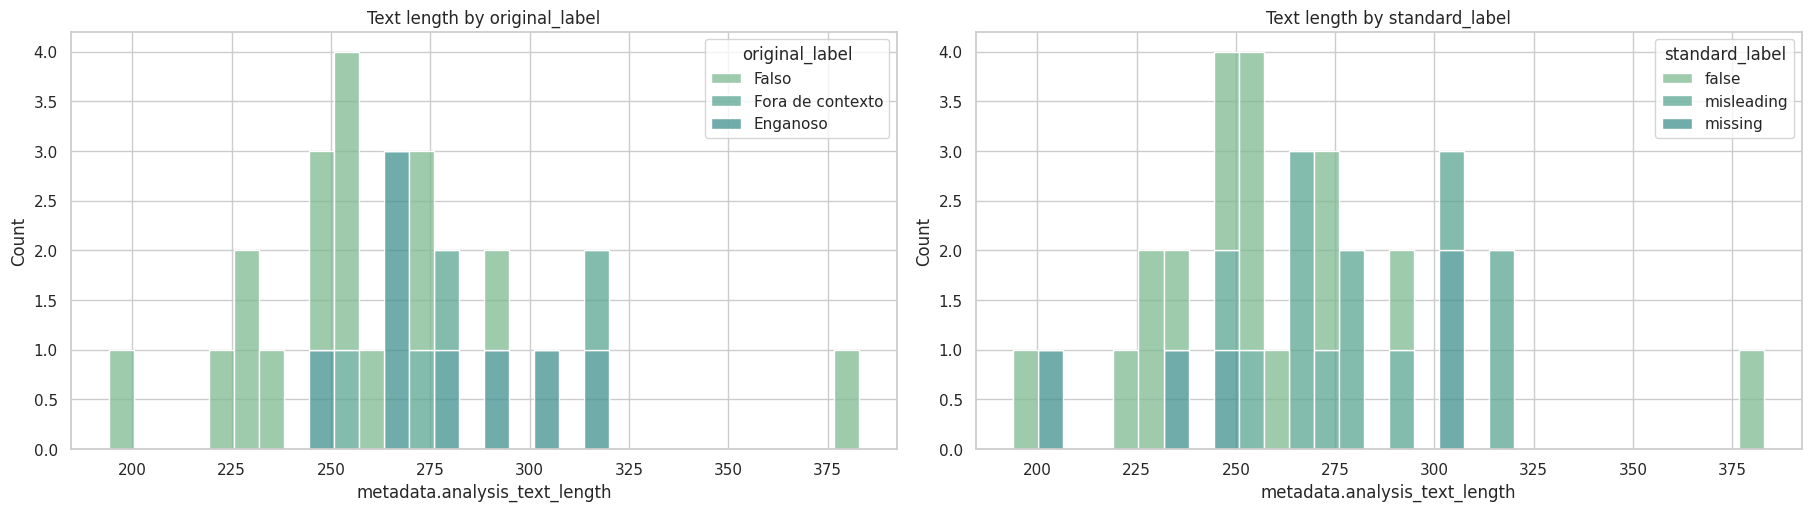

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5), constrained_layout=True)
sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="original_label",
    bins=30,
    multiple="stack",
    ax=axes[0],
)
axes[0].set_title("Text length by original_label")

sns.histplot(
    data=processed_df,
    x="metadata.analysis_text_length",
    hue="standard_label",
    bins=30,
    multiple="stack",
    ax=axes[1],
)
axes[1].set_title("Text length by standard_label")
plt.show()

## Category, topic/tag, temporal distribution, and data quality

In [6]:
topic_counts = raw_df["topics"].explode().dropna().value_counts().head(20)
tag_counts = raw_df["tags"].explode().dropna().value_counts().head(20)
category_counts = processed_df["category"].value_counts(dropna=False).head(20)

display(category_counts.rename_axis("category").reset_index(name="count"))
display(topic_counts.rename_axis("topic").reset_index(name="count"))
display(tag_counts.rename_axis("tag").reset_index(name="count"))

monthly = (
    processed_df.dropna(subset=["published_at_dt"])
    .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())
    .groupby("month")
    .size()
    .reset_index(name="count")
)
display(monthly.tail(24))

missing_fields = (
    raw_df[["title", "claim", "summary", "verdict", "rating", "published_at"]]
    .isna()
    .sum()
    .rename_axis("field")
    .reset_index(name="missing_count")
)
display(missing_fields)

display(
    processed_df.loc[
        processed_df["published_at_dt"].isna(), ["source_record_id", "title", "published_at"]
    ].head(20)
)

,category,count
0,None,32


,topic,count


,tag,count


/tmp/ipykernel_2076760/1119197242.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  .assign(month=lambda df: df["published_at_dt"].dt.to_period("M").dt.to_timestamp())


,month,count
0,2026-03-01,32


,field,missing_count
0,title,0
1,claim,0
2,summary,0
3,verdict,5
4,rating,5
5,published_at,0


,source_record_id,title,published_at


## Cleaning and normalization review

In [7]:
comparison = raw_df.rename(
    columns={
        "item_id": "source_record_id",
        "title": "raw_title",
        "claim": "raw_claim",
        "summary": "raw_summary",
        "published_at": "raw_published_at",
        "verdict": "raw_verdict",
    }
).merge(
    processed_df[
        [
            "source_record_id",
            "title",
            "claim_text",
            "body_text",
            "analysis_text",
            "original_label",
            "standard_label",
            "published_at",
        ]
    ],
    on="source_record_id",
    how="left",
)
display(comparison.head(15))

,source_record_id,agency_id,agency_name,spider,source_url,canonical_url,raw_title,raw_published_at,collected_at,raw_claim,raw_summary,raw_verdict,rating,language,country,topics,tags,entities,source_type,run_id,published_at_dt,collected_at_dt,lag_hours,title_len,claim_len,summary_len,canonical_host,source_equals_canonical,title,claim_text,body_text,analysis_text,original_label,standard_label,published_at
0,4c2d531d4d8d26fac69494b276e5ba74e37f313150ad073b7b8b01b3632b50bf,estadao_verifica,Estadao Verifica,estadao_verifica,https://www.estadao.com.br/estadao-verifica/video-caminhoes-tunel-misseis-ira-falso-inteligencia-artificial/,/estadao-verifica/video-caminhoes-tunel-misseis-ira-falso-inteligencia-artificial/,Vídeo não mostra caminhões com mísseis saindo de túnel no Irã; conteúdo foi criado com IA,2026-03-15T02:39:09+00:00,2026-03-15T02:39:09+00:00,Vídeo mostra caminhões carregados com mísseis saindo de túnel no Irã.,Imagem tem distorções características de arquivos gerados com inteligência artificial,Falso,1,pt-br,BR,[],[],[],ClaimReview,20260315T010005Z-1d265f16,2026-03-15 02:39:09+00:00,2026-03-15 02:39:09+00:00,0.000000,89,69,85,NaN,0.0,Vídeo não mostra caminhões com mísseis saindo de túnel no Irã; conteúdo foi criado com IA,Vídeo mostra caminhões carregados com mísseis saindo de túnel no Irã.,Imagem tem distorções características de arquivos gerados com inteligência artificial,vídeo não mostra caminhões com mísseis saindo de túnel no irã; conteúdo foi criado com ia vídeo mostra caminhões carregados com mísseis saindo de túnel no i...,Falso,false,2026-03-15T02:39:09+00:00
1,59403d947743376781218109b37a4cbd0fea7f1aaa97926c08d9472fc5844609,estadao_verifica,Estadao Verifica,estadao_verifica,https://www.estadao.com.br/estadao-verifica/fora-de-contexto-donald-trump-endureceu-tom-brasil/,/estadao-verifica/fora-de-contexto-donald-trump-endureceu-tom-brasil/,Fala de Trump lamentando relação abalada com o Brasil circula fora de contexto,2026-03-15T02:39:09+00:00,2026-03-15T02:39:09+00:00,Donald Trump endureceu o tom contra o Brasil,"Declaração foi feita em setembro de 2025, antes de reaproximação entre os dois países; americano teceu elogios a Lula recentemente",Fora de contexto,3,pt-br,BR,[],[],[],ClaimReview,20260315T010005Z-1d265f16,2026-03-15 02:39:09+00:00,2026-03-15 02:39:09+00:00,0.000000,78,45,130,NaN,0.0,Fala de Trump lamentando relação abalada com o Brasil circula fora de contexto,Donald Trump endureceu o tom contra o Brasil,"Declaração foi feita em setembro de 2025, antes de reaproximação entre os dois países; americano teceu elogios a Lula recentemente",fala de trump lamentando relação abalada com o brasil circula fora de contexto donald trump endureceu o tom contra o brasil declaração foi feita em setembro...,Fora de contexto,misleading,2026-03-15T02:39:09+00:00
2,0a26335ecc0a19fb79aba59d86627ff0b64211a9ae5583bb506e6ff40f6daeb9,estadao_verifica,Estadao Verifica,estadao_verifica,https://www.estadao.com.br/estadao-verifica/china-base-militar-secreta-salvador-entenda/,https://www.estadao.com.br/estadao-verifica/china-base-militar-secreta-salvador-entenda/,Relatório dos EUA não fala em ‘base militar secreta’ chinesa em Salvador; saiba o que diz documento,2026-03-04T12:57:06-03:00,2026-03-15T02:39:09+00:00,"Texto divulgado pelo Congresso americano afirma que chineses têm acesso a instalação de empresa brasileira em Tucano, no sertão baiano; parlamentares questi...","Texto divulgado pelo Congresso americano afirma que chineses têm acesso a instalação de empresa brasileira em Tucano, no sertão baiano; parlamentares questi...",NaN,NaN,pt-br,BR,[],[],[],NewsArticle,20260315T010005Z-1d265f16,2026-03-04 15:57:06+00:00,2026-03-15 02:39:09+00:00,250.700833,99,204,204,www.estadao.com.br,1.0,Relatório dos EUA não fala em ‘base militar secreta’ chinesa em Salvador; saiba o que diz documento,"Texto divulgado pelo Congresso americano afirma que chineses têm acesso a instalação de empresa brasileira em Tucano, no sertão baiano; parlamentar

## NLP outputs

In [8]:
lemma_counts = (
    processed_df["lemmatized_text"].str.split().explode().dropna().value_counts().head(20)
)
display(lemma_counts.rename_axis("lemma").reset_index(name="count"))

entity_series = processed_df["entities"].explode().dropna()
if entity_series.empty:
    entity_df = pd.DataFrame(columns=["text", "label", "start_char", "end_char"])
else:
    entity_df = pd.json_normalize(entity_series)

display(entity_df.head(20))
display(entity_df["label"].value_counts().rename_axis("label").reset_index(name="count"))
display(processed_df[["source_record_id", "text_without_stopwords", "lemmatized_text"]].head(10))

,lemma,count
0,de,134
1,o,121
2,em,69
3,ser,42
4,que,38
5,e,32
6,não,27
7,por,20
8,com,19
9,vídeo,16


,text,label,start_char,end_char
0,irã,LOC,58,61
0,irã,LOC,155,158
1,trump,PER,8,13
1,brasil,LOC,47,53
1,donald trump,PER,79,91
1,brasil declaração,MISC,117,134
1,lula,PER,237,241
2,eua,LOC,14,17
2,salvador,LOC,64,72
3,r$ 24 mil,ORG,193,202


,label,count
0,LOC,51
1,PER,48
2,ORG,17
3,MISC,3


,source_record_id,text_without_stopwords,lemmatized_text
0,4c2d531d4d8d26fac69494b276e5ba74e37f313150ad073b7b8b01b3632b50bf,vídeo mostra caminhões mísseis saindo túnel irã conteúdo criado ia vídeo mostra caminhões carregados mísseis saindo túnel irã imagem distorções característi...,vídeo não mostrar caminhão com míssil sair de túnel em o irã conteúdo ser criar com ir vídeo mostrar caminhão carregar com míssil sair de túnel em o irã ima...
1,59403d947743376781218109b37a4cbd0fea7f1aaa97926c08d9472fc5844609,fala trump lamentando abalada brasil circula contexto donald trump endureceu tom brasil declaração feita setembro 2025 reaproximação países americano teceu ...,falar de trump lamentar relação abalar com o brasil circular fora de contexto donald trump endurecer o tom contra o brasil declaração ser fazer em setembro ...
2,0a26335ecc0a19fb79aba59d86627ff0b64211a9ae5583bb506e6ff40f6daeb9,relatório eua fala base militar secreta chinesa salvador saiba documento texto divulgado congresso americano afirma chineses acesso instalação empresa brasi...,relatório de o eua não falar em base militar secreto chinês em salvador saber o que dizer documento texto divulgar por o congresso americano afirmar que chi...
3,c0f318b80eff9dbdeb3639753f13677e20e81f036b344d3780da79aa3aeff122,vídeo distorce edital universidade sugere contratação generalizada professores palestinos governo federal contratando professores palestinos venezuelanos cu...,vídeo distorcer edital de universidade e sugerir contratação generalizado de professor palestino governo federal estar contratar professor palestino venezue...
4,0056de5d37f744ec96412ea91fa213503e36d62067d516a20e4e3c8c80ac877d,vídeo mostra caça atingido míssil guerra irã simulação voo eua x irã caça atingido míssil imagens viralizaram instagram fossem cenas conflito estados unidos...,vídeo que mostrar caça atingir por míssil não ser de guerra em o irã mas sim de simulação de voo eua x irã momento em que caça ser atingir por um míssil ima...
5,bc118830aa0409621c6875eeecc9db7d012b95f591ef12cbe9d9a509a00166b1,postagens compartilham imagem ia alegar irã desenhos iscas militares imagens mostram irã pintou desenhos aviões chão enganar bombardeios estados unidos isra...,postagem compartilhar imagem de ia para alegar que irã usar desenho como isca militar imagem mostrar que o irã pintar desenho de avião em o chão para engana...
6,7e8b316e8f6e47826143f14c156958e0068caee64a61c06eef55227152da84d8,entrevista | imagens militares americanos rendidos irã feitas ia irã captura 180 militares americanos realizadas incursões forças eua território iraniano há...,entrevista | imagem de militar americano rendir em o irã ser fazer com ir irã captura 180 militar americano até o momento não ser realizar incursão de força...
7,0d598dd4c038dbbff51fdd3e619718315137bc5cdeb2eb3c2fd77eadcdd804bb,estátua baal queimada irã comemoração ataques eua israel iranianos queimaram estátua baal ataque eua israel irã atos ocorreram diversas cidades país dia 11 ...,estátua de baal não ser queimar em o irã em comemoração a ataque de o eua e de israel iraniano queimar estátua de baal após ataque de o eua e israel a o irã...
8,998553e0ae3d83c2ae53538dffc4e446020a45f10ff60cbe7cf1517b15d31341,vídeo inventa surto vorcaro prisão delação lula stf daniel vorcaro surta prisão delata lula membros stf conteúdo criado canal inteligência artificial divulg...,vídeo inventar surto de vorcaro em o prisão e delação contra lula e stf daniel vorcaro surtar em o prisão e delatar lula e membro de o stf conteúdo ser cria...
9,f9cbc73c415c09f3c64e33a4bba32f8d4f5c02e023484ec87e1f277e27c388ab,vídeo senadores 41 assinaturas impeachment moraes agosto 2025 oposição conseguem 41 assinaturas senadores pedir impeachment alexandre moraes conteúdo virali...,vídeo em que senador dizer ter 41 assinatura para impeachment de moraes ser de agosto de 2025 oposição conseguir 41 assinatura de senador para pedir impeach...


## Export processed JSONL

In [10]:
export_info = eu.export_processed_records(
    DATA_DIR,
    SPIDER,
    records=processed_records,
    selection=selection,
    snapshot_id=SNAPSHOT_ID,
)

display(
    pd.DataFrame(
        [
            {
                "snapshot_id": export_info["snapshot_id"],
                "record_count": export_info["record_count"],
                "spider_path": str(export_info["spider_path"]),
                "combined_path": str(export_info["combined_path"]),
                "manifest_path": str(export_info["manifest_path"]),
            }
        ]
    )
)

,snapshot_id,record_count,spider_path,combined_path,manifest_path
0,20260316T000118Z-estadao_verifica,32,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260316T000118Z-estadao_verifica/spiders/estadao_verifica.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260316T000118Z-estadao_verifica/factcheck_scrape_unified.jsonl,/home/diacrono/Documentos/repositorios/fact-checking-scrape/data/processed/20260316T000118Z-estadao_verifica/manifest.json
